# Text Classification: RNN vs. Transformer
Notebook dùng dataset Kaggle:
* https://www.kaggle.com/datasets/bhavikardeshna/yahoo-email-classification


## Giới thiệu về Tập dữ liệu (Introduction)
Tập dữ liệu Yahoo! Answers Topic Classification được trích xuất từ nghiên cứu của **Xiang Zhang, Junbo Zhao, và Yann LeCun (NIPS 2015)**.

* Quy mô: 1.400.000 mẫu huấn luyện và 60.000 mẫu kiểm thử.
* Cấu trúc: Mỗi mẫu bao gồm 3 phần văn bản: Tiêu đề (Title), Nội dung câu hỏi (Content) và Câu trả lời hay nhất (Best Answer).
* Số lớp: 10 lớp chủ đề từ Xã hội, Khoa học đến Chính trị.

## Cấu trúc thực hiện
1. Cài đặt và tải dữ liệu từ Kaggle
2. Exploratory Data Analysis (EDA)
3. Tiền xử lý dữ liệu và kiểm chứng
4. Thiết lập dữ liệu, chia tập dữ liệu theo tỷ lệ 9/1 bằng phương pháp Stractified Sampling
4. Định nghĩa mô hình RNN (LSTM) và Transformer Encoder
5. Huấn luyện và so sánh mô hình theo các chỉ số:
   * Accuracy, Precision (macro), Recall (macro), F1 (macro).
   * Inference time
6. Phân tích lỗi (confusion matrix, top cặp lớp nhầm lẫn)
7. Interpretability (Saliency Map)
8. Efficiency
9. Nhận xét và kết luận


## 1\. Cài đặt và tải dữ liệu  từ Kaggle
Trong phần này, nhóm cài đặt thư viện `kagglehub` để tải tập dữ liệu trực tiếp từ Kaggle và thiết lập các thư viện cần thiết cho việc xử lý ngôn ngữ tự nhiên (NLP).

In [1]:
import kagglehub
import pandas as pd
import csv

In [2]:
# Download latest version
path = kagglehub.dataset_download("bhavikardeshna/yahoo-email-classification")

print("Path to dataset files:", path)

100%|██████████| 309M/309M [00:02<00:00, 124MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/bhavikardeshna/yahoo-email-classification/versions/1


In [3]:
import os

# Construct the full path to train.csv
train_path = os.path.join(path, "train.csv")
column_names = ['label', 'title', 'content', 'answer']

data = []
print("Loading data from kagglehub path...")

with open(train_path, 'r', encoding='utf-8', errors='ignore') as f:
    # Using the robust csv.reader method we perfected earlier
    reader = csv.reader(f, delimiter=',', quotechar='"')
    for row in reader:
        if len(row) >= 4:
            data.append(row[:4])

df = pd.DataFrame(data, columns=column_names)

# Standardize labels (0-9)
df['label'] = pd.to_numeric(df['label'], errors='coerce')
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int) - 1

print(f"Successfully loaded {len(df)} samples from Kaggle.")

Loading data from kagglehub path...
Successfully loaded 1400000 samples from Kaggle.


## 2\. Exploratory Data Analysis (EDA)
Mục tiệu: thực hiện phân tích sơ bộ để kiểm tra tính cân bằng của các lớp chủ đề và phân phối độ dài của văn bản, từ đó đưa ra các quyết định cho tham số của mô hình sau này.

### 2.1. Trực quan hóa sự phân bổ các chủ đề


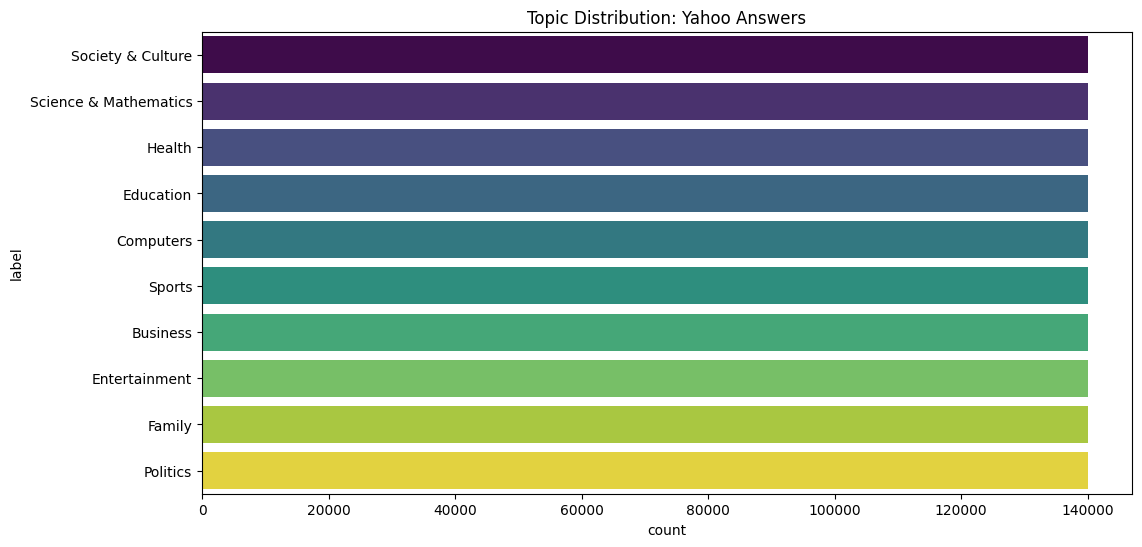

In [ ]:
# Visualize topic distribution to ensure class balance across the dataset
import matplotlib.pyplot as plt
import seaborn as sns
topic_names = ["Society & Culture", "Science & Mathematics", "Health", "Education",
               "Computers", "Sports", "Business", "Entertainment", "Family", "Politics"]

plt.figure(figsize=(12, 6))
sns.countplot(y='label', data=df, palette='viridis', hue='label', legend=False)
plt.yticks(ticks=range(10), labels=topic_names)
plt.title('Topic Distribution: Yahoo Answers')
plt.show()

### 2.2. Thông số thống kê về độ dài văn bản

In [4]:
# Combine text fields and calculate descriptive statistics for word counts
df[['title', 'content', 'answer']] = df[['title', 'content', 'answer']].fillna("")
df['full_text'] = df['title'] + " " + df['content'] + " " + df['answer']
df['text_len'] = df['full_text'].apply(lambda x: len(str(x).split()))

print(f"Average: {df['text_len'].mean():.2f} words")
print(f"95th percentile: {df['text_len'].quantile(0.95):.2f} words")

Average: 91.56 words
95th percentile: 273.00 words


### 2.3. Xác định ngưỡng cắt tối ưu cho RNN và Transformer.

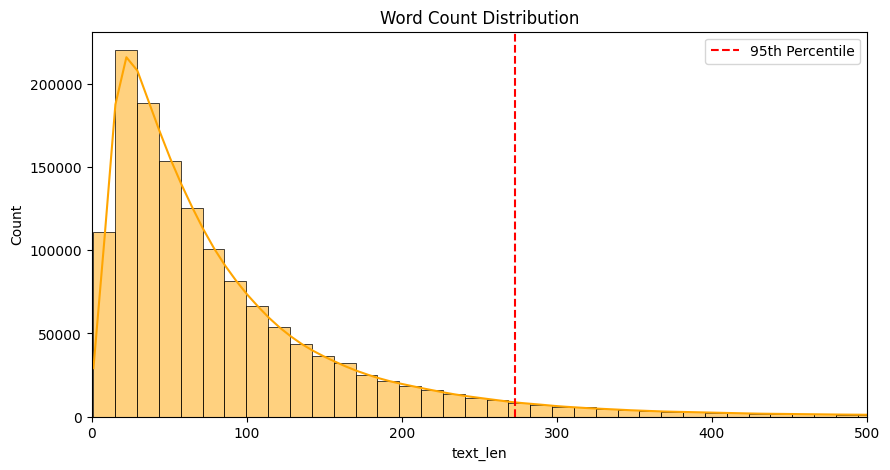

In [ ]:
# Visualize word count distribution and the 95th percentile threshold
plt.figure(figsize=(10, 5))
sns.histplot(df['text_len'], bins=100, kde=True, color='orange')
plt.axvline(df['text_len'].quantile(0.95), color='r', linestyle='--', label='95th Percentile')
plt.title('Word Count Distribution')
plt.xlim(0, 500)
plt.legend()
plt.show()

### 2.4. Xác định độ dài ngưỡng tối đa
Thiết lập tham số `max_seq_len` dựa trên bách phân vị thứ 95 để tối ưu hóa hiệu suất và tài nguyên tính toán cho mô hình.

In [ ]:
# Set max_seq_len at the 95th percentile to cover most samples efficiently
MAX_SEQ_LEN = int(df['text_len'].quantile(0.95))
print(f"Final MAX_SEQ_LEN: {MAX_SEQ_LEN}")

Final MAX_SEQ_LEN: 273


## 3\. Tiền xử lý dữ liệu và kiểm chứng

### 3.1. Làm sạch dữ liệu văn bản
Loại bỏ nhiễu (thẻ HTML, ký tự đặc biệt) và chuẩn hóa văn bản về dạng chữ thường để giảm kích thước từ điển cho mô hình.

In [5]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text_final(text):
    text = str(text).lower()
    # 1. Remove HTML tags (important for Yahoo Answers)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply to the cleaned_text column
# 1. Clean text
df['cleaned_text'] = df['full_text'].apply(clean_text_final)

# 2. Remove empty
df = df[df['cleaned_text'].str.strip() != ""]

# 3. Remove duplicates
df = df.drop_duplicates(subset=['cleaned_text'])


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


### 3.2. Kiểm tra dữ liệu trùng lặp và tần suất từ
Thống kê các mẫu bị trùng và phân tích các từ đơn xuất hiện nhiều nhất để đảm bảo dữ liệu đã được làm sạch hiệu quả.

Number of duplicate samples: 0


C:\Users\Admin\AppData\Local\Temp\ipykernel_25140\3911603132.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='magma', legend=False)


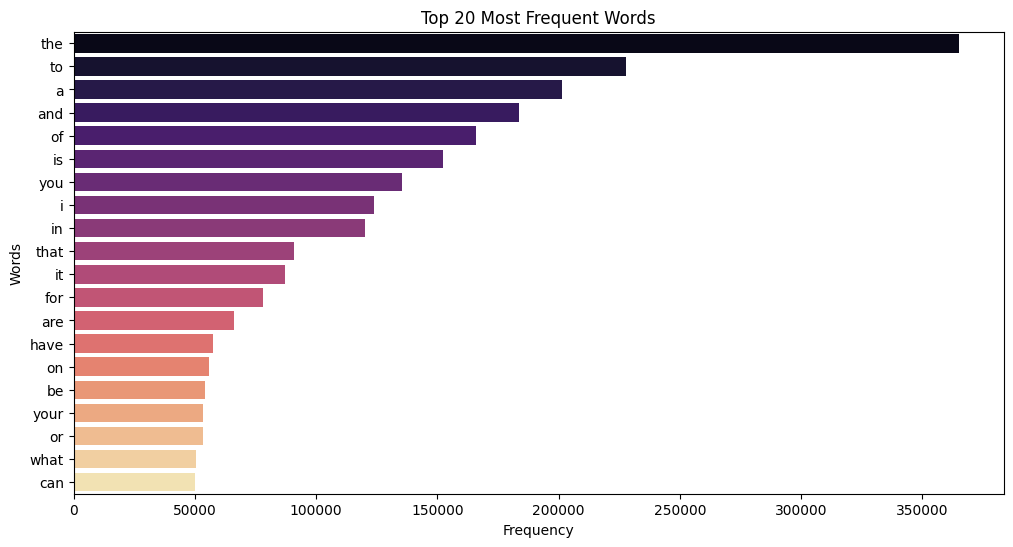

In [ ]:
from collections import Counter

# Count duplicate samples based on cleaned text
duplicates = df.duplicated(subset=['cleaned_text']).sum()
print(f"Number of duplicate samples: {duplicates}")

# Calculate word frequency for the top 100,000 samples
all_words = " ".join(df['cleaned_text'].iloc[:100000]).split()
word_freq = Counter(all_words)

# Visualize the Top 20 most frequent words
common_words = word_freq.most_common(20)
words, counts = zip(*common_words)

plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(words), palette='magma', legend=False)
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

### 3.3. Phân tích cụm từ phổ biến (N-gram Analysis)
Sử dụng Bi-grams để quan sát các cụm hai từ đi kèm nhau, giúp hiểu sâu hơn về ngữ cảnh của các chủ đề trong tập dữ liệu.

C:\Users\Admin\AppData\Local\Temp\ipykernel_25140\1338967881.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts_bi), y=list(words_bi), palette='rocket')


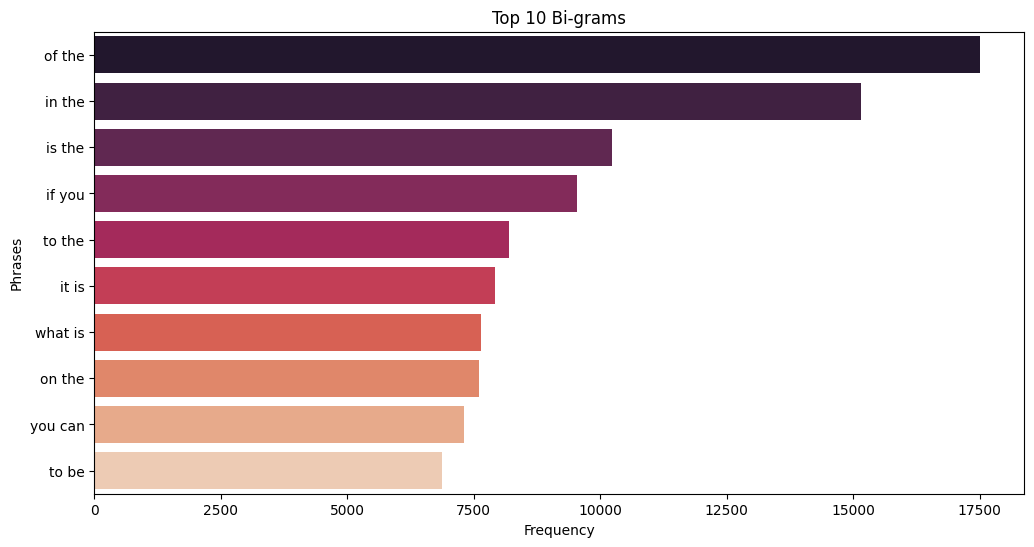

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngram(corpus, n=None, top_k=10):
    """Function to extract the top k n-grams from the corpus"""
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Extract and visualize Top 10 Bi-grams (2-word phrases)
top_bi_grams = get_top_ngram(df['cleaned_text'].iloc[:50000], n=2)
words_bi, counts_bi = zip(*top_bi_grams)

plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts_bi), y=list(words_bi), palette='rocket')
plt.title('Top 10 Bi-grams')
plt.xlabel('Frequency')
plt.ylabel('Phrases')
plt.show()

### 3.4. Kiểm chứng dữ liệu sau khi làm sạch
Sử dụng biểu đồ WordCloud để quan sát trực quan các từ khóa đặc trưng nhất trong tập dữ liệu sau khi loại bỏ nhiễu.

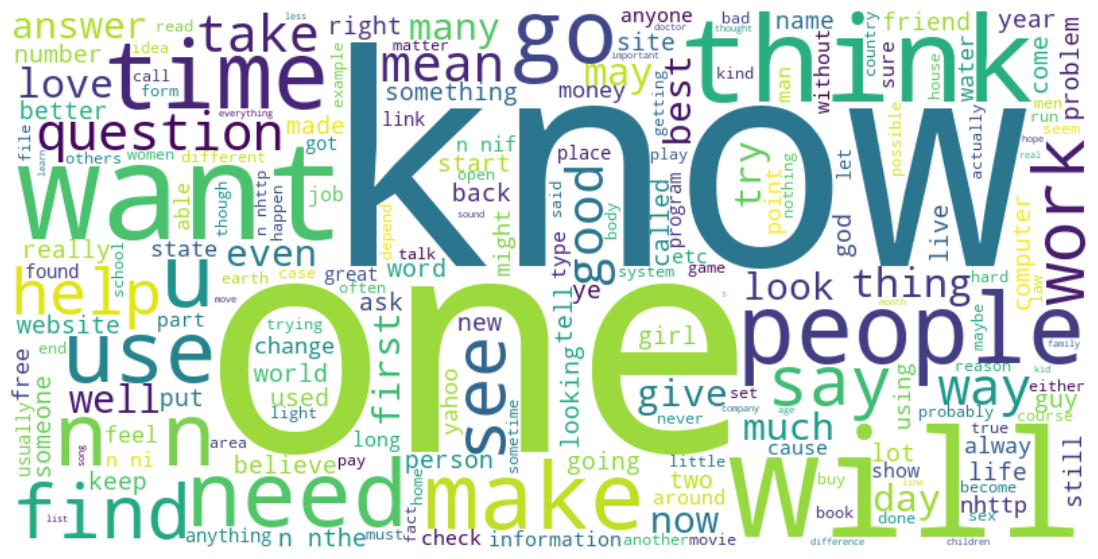

In [ ]:
from wordcloud import WordCloud

# Create wordcloud for the whole data or for each topic
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(all_words))

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## 4\. Thiết lập dữ liệu, chia tập dữ liệu theo tỷ lệ 9/1 bằng phương pháp Stractified Sampling

### 4.1. Chuẩn hóa nhãn và Làm sạch lần cuối
Đảm bảo nhãn dữ liệu ở định dạng số nguyên và loại bỏ triệt để các mẫu dữ liệu trống sau quá trình xử lý văn bản.

In [6]:
# Ensure the label is in integer format (0-9) for compatibility with Loss Functions
df['label'] = df['label'].astype(int)

# Remove any rows that might have become empty or contain only whitespace after cleaning
df = df.dropna(subset=['cleaned_text'])
df = df[df['cleaned_text'].str.strip() != ""]

# Select only necessary columns to optimize memory usage
df_final = df[['label', 'cleaned_text']].reset_index(drop=True)

print(f"Data ready for splitting. Total samples: {df_final.shape[0]}")

Data ready for splitting. Total samples: 1399897


### 4.2. Phân tách tập dữ liệu Huấn luyện và Kiểm định
Sử dụng phương pháp *Stratified Split* để chia dữ liệu theo tỷ lệ 9:1, đảm bảo sự cân bằng giữa các chủ đề trong cả hai tập.

In [7]:
from sklearn.model_selection import train_test_split

# We split the dataset into 90% Training and 10% Validation
# 'stratify' ensures that each topic is represented proportionally in both sets
train_df, val_df = train_test_split(
    df_final,
    test_size=0.1,
    random_state=42,
    stratify=df_final['label']
)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

Training samples: 1259907
Validation samples: 139990


### 4.3. Lưu trữ dữ liệu đã xử lý
Xuất dữ liệu ra file CSV để có thể tái sử dụng nhanh chóng mà không cần thực hiện lại toàn bộ quy trình tiền xử lý.

In [8]:
# Saving the cleaned datasets locally or to Google Drive to avoid re-processing
# index=False prevents pandas from adding an extra 'unnamed' column
train_df.to_csv('yahoo_train_final.csv', index=False)
val_df.to_csv('yahoo_val_final.csv', index=False)

print("Processed datasets have been saved successfully!")

Processed datasets have been saved successfully!


### 4.4. Xây dựng pipeline dữ liệu và số hóa cho mô hình RNN (LSTM)
**Phương pháp tiếp cận (Approach)**:

Ở giai đoạn này, nhóm thiết lập một cấu trúc xử lý dữ liệu khép kín từ văn bản thô sang dạng tensor số. Việc kết hợp xây dựng từ điển (Vocabulary) và cấu trúc hóa tập dữ liệu (Dataset) trong cùng một quy trình giúp đảm bảo tính đồng nhất về chỉ số (indices) giữa các tập dữ liệu.

**Các thành phần cốt lõi trong Block Code**:
1. **Xây dựng bộ từ điển tùy chỉnh**:
   * Mã hóa: Chuyển đổi các từ thành số nguyên dựa trên tần suất xuất hiện (`most_common`). Việc giới hạn `max_vocab_size=20000` giúp loại bỏ nhiễu từ các lỗi chính tả hoặc từ hiếm.

   * Token đặc biệt: Sử dụng `<pad>` (Index 0) để đồng bộ độ dài và `<unk>` (Index 1) để xử lý các từ mới không xuất hiện trong tập huấn luyện.
2. **Cấu trúc hóa dữ liệu (LSTMDataset Class)**:
   * Tokenization: Tách câu thành các đơn vị từ dựa trên biểu thức chính quy (Regex).
   * Numericalization: Chuyển câu văn thành chuỗi số. Nếu gặp từ ngoài từ điển, hệ thống tự động gán nhãn `<unk>`.
   * Đồng bộ độ dài (Padding & Truncating): Cố định mọi chuỗi đầu vào ở mức `MAX_SEQ_LEN = 150`. Đây là ngưỡng tối ưu được xác định từ bước EDA để giữ lại thông tin quan trọng nhất của câu hỏi.
3. **Quản lý nạp dữ liệu (DataLoaders)**:
   * Chuyển đổi Dataset thành các Batch dữ liệu. Sử dụng `shuffle=True` cho tập huấn luyện để phá vỡ tính thứ tự, giúp mô hình học được các đặc trưng tổng quát thay vì học vẹt theo trình tự dữ liệu.

In [9]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification


In [10]:
# ---------------------------------------------------------
# 1. THIẾT LẬP THIẾT BỊ (CUDA) & TẢI DỮ LIỆU
# ---------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang chạy trên thiết bị: {device}")

# Tải lại dữ liệu đã qua xử lý của bạn
train_df = pd.read_csv('yahoo_train_final.csv').fillna("")
val_df = pd.read_csv('yahoo_val_final.csv').fillna("")

# Số lượng nhãn của tập Yahoo Answers là 10
NUM_CLASSES = 10
MAX_SEQ_LEN = 150


Đang chạy trên thiết bị: cpu


In [11]:
BATCH_SIZE = 128
# ---------------------------------------------------------
# 2. CHUẨN BỊ DỮ LIỆU CHO LSTM (Tự xây dựng từ vựng thuần Python)
# ---------------------------------------------------------
from collections import Counter
import re

def basic_tokenizer(text):
    return re.findall(r'\b\w+\b', text)

def build_vocab(texts, max_vocab_size=20000):
    counter = Counter()
    for text in texts:
        counter.update(basic_tokenizer(text))

    # Khởi tạo từ điển với các token đặc biệt
    vocab = {"<pad>": 0, "<unk>": 1}

    # Lấy các từ phổ biến nhất đưa vào từ điển
    for word, _ in counter.most_common(max_vocab_size):
        if word not in vocab:
            vocab[word] = len(vocab)
    return vocab

print("Đang xây dựng tập từ vựng cho LSTM...")
vocab = build_vocab(train_df['cleaned_text'])
print(f"Kích thước tập từ vựng: {len(vocab)} từ")

class LSTMDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        label = self.labels.iloc[idx]

        # Chuyển đổi text thành các con số (indices), nếu từ lạ thì gán là <unk>
        tokens = [self.vocab.get(w, self.vocab["<unk>"]) for w in basic_tokenizer(text)]

        # Padding hoặc Truncating
        if len(tokens) < self.max_len:
            tokens += [self.vocab["<pad>"]] * (self.max_len - len(tokens))
        else:
            tokens = tokens[:self.max_len]

        return torch.tensor(tokens, dtype=torch.long), torch.tensor(label, dtype=torch.long)



# Cập nhật DataLoader cho LSTM

train_loader_lstm = DataLoader(LSTMDataset(train_df['cleaned_text'], train_df['label'], vocab, MAX_SEQ_LEN),
                               batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader_lstm = DataLoader(LSTMDataset(val_df['cleaned_text'], val_df['label'], vocab, MAX_SEQ_LEN),
                             batch_size=BATCH_SIZE,  pin_memory=True)

Đang xây dựng tập từ vựng cho LSTM...
Kích thước tập từ vựng: 20002 từ


## 5\. Định nghĩa mô hình LSTM và Transformer Encoder

### 5.1. Mô hình Bi-LSTM (Bidirectional Long Short-term Memory)
**Mục tiêu**:

Đối với bài toán phân loại văn bản dài như Yahoo Answers, thách thức lớn nhất là việc duy trì thông tin ngữ cảnh xuyên suốt chuỗi. Nhóm lựa chọn kiến trúc Bi-directional LSTM (LSTM hai chiều) để mô hình có thể khai thác thông tin từ cả hai hướng (quá khứ và tương lai), giúp việc biểu diễn ngữ nghĩa của mỗi từ trở nên trọn vẹn hơn.

**Phân tích các thành phần cốt lõi**:

* **Lớp Nhúng (Embedding Layer)**: Thực hiện chuyển hóa các token số nguyên thành vector dày đặc. Tham số padding_idx được thiết lập nhằm loại bỏ các giá trị đệm khỏi quá trình tính toán, giúp tập trung tài nguyên vào các nội dung có giá trị ngữ nghĩa.

* **Cấu trúc Stacked Bi-LSTM**: Mô hình sử dụng 2 lớp LSTM chồng phổ (`num_layers=2`) kết hợp tính năng hai chiều. Thiết lập này giúp phân tầng việc học đặc trưng: từ các cấu trúc cú pháp cơ bản ở lớp dưới đến các khái niệm chủ đề trừu tượng ở lớp trên.

* **Kiểm soát Overfitting**: Kỹ thuật `dropout=0.3` được áp dụng giữa các lớp mạng để hạn chế hiện tượng học vẹt và tăng khả năng tổng quát hóa trên các tập dữ liệu thực tế.

* **Hợp nhất Trạng thái (Concatenation)**: Trạng thái ẩn (hidden state) của hai chiều được kết nối trực tiếp tại bước cuối cùng. Vector tổng hợp này đóng vai trò là bản tóm tắt nội dung, cung cấp đầu vào đầy đủ nhất cho lớp phân loại tuyến tính.

In [12]:
# ---------------------------------------------------------
# 3. ĐỊNH NGHĨA MÔ HÌNH LSTM
# ---------------------------------------------------------
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=vocab["<pad>"])
        # batch_first=True giúp đầu vào có định dạng (batch, seq, feature)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2, batch_first=True, bidirectional=True, dropout=0.3)
        self.fc = nn.Linear(hidden_dim * 2, num_classes) # *2 vì bidirectional

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        # Lấy hidden state của lớp cuối cùng để phân loại
        hidden_cat = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        return self.fc(hidden_cat)

model_lstm = LSTMClassifier(len(vocab), embed_dim=128, hidden_dim=256, num_classes=NUM_CLASSES).to(device)

### 5.2. Mô hình Transformer (DistilBERT)
**Mục tiêu**:

Sử dụng DistilBERT làm mô hình đối chiếu với LSTM. Lựa chọn này tận dụng cơ chế Self-Attention để xử lý ngữ cảnh song song, đảm bảo sự cân bằng giữa độ chính xác và tài nguyên GPU.

**Phân tích các thành phần cốt lõi**:

* **Tokenization (WordPiece)**: Phân rã văn bản thành sub-words. Phương pháp này xử lý hiệu quả các từ lạ (Out-of-Vocabulary) bằng cách biểu diễn qua các gốc từ có sẵn.

* **Attention Mask**: Trích xuất song song với input_ids để chỉ định các vị trí token thực tế, loại bỏ hoàn toàn ký tự đệm (padding) khỏi quá trình tính toán trọng số.

* **Freeze Backbone**: Thiết lập `requires_grad = False` cho toàn bộ các lớp Transformer Encoder.

  * Mục đích: Giữ nguyên đặc trưng ngôn ngữ tiền huấn luyện và chỉ cập nhật trọng số cho lớp phân loại (Classification Head).

  * Hệ quả: Giảm tham số tối ưu, rút ngắn thời gian huấn luyện và hạn chế quá khớp (overfitting).

In [13]:
# ---------------------------------------------------------
# 4. CHUẨN BỊ DỮ LIỆU & MÔ HÌNH TRANSFORMER (Pretrained DistilBERT)
# ---------------------------------------------------------
model_name = "distilbert-base-uncased"
tokenizer_tf = AutoTokenizer.from_pretrained(model_name)

class TransformerDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        label = self.labels.iloc[idx]

        # SỬA LỖI TẠI ĐÂY: Dùng trực tiếp self.tokenizer() thay vì self.tokenizer.encode_plus()
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Chạy lại 2 dòng này để nạp lại dữ liệu với class mới vừa sửa

train_loader_tf = DataLoader(TransformerDataset(train_df['cleaned_text'], train_df['label'], tokenizer_tf, MAX_SEQ_LEN),
                             batch_size=128, shuffle=True,  pin_memory=True)
val_loader_tf = DataLoader(TransformerDataset(val_df['cleaned_text'], val_df['label'], tokenizer_tf, MAX_SEQ_LEN),
                           batch_size=128, pin_memory=True)
# Tải mô hình pretrained cho Sequence Classification
model_tf = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=NUM_CLASSES
)
##### freeze backbone

for param in model_tf.distilbert.parameters():
    param.requires_grad = False

model_tf.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


## 6\. Huấn luyện và so sánh mô hình theo các chỉ số

### 6.1. Huấn luyện và đánh giá
**Cấu trúc thực thi**:

Hàm `train_and_evaluate` được thiết kế theo dạng đóng gói (encapsulation), cho phép dùng chung một logic huấn luyện cho cả hai kiến trúc LSTM và Transformer. Quy trình này bao gồm các kỹ thuật tối ưu hóa giúp tăng tốc độ tính toán và đảm bảo tính ổn định của mô hình.

**Các thành phần kỹ thuật cốt lõi**:

* **Mixed Precision Training (AMP)**: Sử dụng `torch.cuda.amp` (Autocast & GradScaler). Kỹ thuật này tự động điều chỉnh độ chính xác của các phép toán giữa Float32 và Float16, giúp tiết kiệm bộ nhớ GPU và đẩy nhanh tốc độ huấn luyện mà không làm giảm độ chính xác của mô hình.

* **Early Stopping**: Cơ chế giám sát dựa trên patience. Nếu Validation Loss không cải thiện sau một số epoch nhất định, quá trình huấn luyện sẽ dừng lại để ngăn chặn hiện tượng quá khớp (Overfitting), đồng thời khôi phục lại trạng thái tốt nhất của mô hình (`best_model_state`).

* **Quản lý bộ nhớ**: Sử dụng `.detach().cpu()` khi tính toán các chỉ số (Accuracy, F1). Thao tác này tách các tensor khỏi đồ thị tính toán (computation graph) và đưa về RAM, tránh tình trạng tràn bộ nhớ VRAM của GPU trong quá trình lặp.

* **Đánh giá đa chiều**: Bên cạnh Loss, hệ thống theo dõi song song Accuracy và Macro F1-Score. Chỉ số F1-Score đặc biệt quan trọng trong bài toán này để đánh giá sự cân bằng của mô hình trên cả 10 chủ đề khác nhau của Yahoo Answers.

In [ ]:
import copy
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score

# ---------------------------------------------------------
# 5. VÒNG LẶP HUẤN LUYỆN (In đầy đủ Train/Val Accuracy & Early Stopping)
# ---------------------------------------------------------
def train_and_evaluate(model, train_loader, val_loader,optimizer=None,model_type="lstm", epochs=20, patience=3):
    criterion = nn.CrossEntropyLoss()
    if optimizer is None:
            lr = 1e-3 if model_type == "lstm" else 2e-5
            optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    print(f"\n{'='*55}")
    print(f"🚀 BẮT ĐẦU HUẤN LUYỆN: {model_type.upper()} (Max Epochs: {epochs}, Patience: {patience})")
    print(f"{'='*55}")

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    scaler = torch.cuda.amp.GradScaler()
    for epoch in range(epochs):
        # ==========================================
        # 1. PHA HUẤN LUYỆN (TRAINING)
        # ==========================================
        model.train()
        total_train_loss = 0
        train_preds, train_labels_list = [], [] # Thêm mảng lưu kết quả Train

        train_progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
        for batch in train_progress:
            optimizer.zero_grad()

            if model_type == "lstm":
                inputs, labels = batch[0].to(device), batch[1].to(device)
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

            else: # transformer
                inputs = batch['input_ids'].to(device)
                masks = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                with torch.cuda.amp.autocast():
                    outputs = model(inputs, attention_mask=masks).logits
                    loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            loss = criterion(outputs, labels)
            total_train_loss += loss.item()

            # Lưu lại dự đoán để tính Train Accuracy (Dùng detach để tránh tràn RAM)
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            train_preds.extend(preds)
            train_labels_list.extend(labels.cpu().numpy())

            train_progress.set_postfix({"loss": f"{loss.item():.4f}"})

        # Tính Train Accuracy
        train_acc = accuracy_score(train_labels_list, train_preds)

        # ==========================================
        # 2. PHA ĐÁNH GIÁ (VALIDATION)
        # ==========================================
        model.eval()
        total_val_loss = 0
        val_preds, val_labels_list = [], []

        val_progress = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]  ", leave=False)
        with torch.no_grad():
            for batch in val_progress:
                if model_type == "lstm":
                    inputs, labels = batch[0].to(device), batch[1].to(device)
                    outputs = model(inputs)
                else:
                    inputs = batch['input_ids'].to(device)
                    masks = batch['attention_mask'].to(device)
                    labels = batch['labels'].to(device)
                    outputs = model(inputs, attention_mask=masks).logits

                val_loss = criterion(outputs, labels)
                total_val_loss += val_loss.item()

                preds = torch.argmax(outputs, dim=1).cpu().numpy()
                val_preds.extend(preds)
                val_labels_list.extend(labels.cpu().numpy())

        # ==========================================
        # 3. TỔNG HỢP VÀ IN KẾT QUẢ EPOCH
        # ==========================================
        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)
        val_acc = accuracy_score(val_labels_list, val_preds)
        val_f1 = f1_score(val_labels_list, val_preds, average='macro')

        print(f"✅ TỔNG KẾT EPOCH {epoch+1}/{epochs}:")
        print(f"   - Train Loss : {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"   - Val Loss   : {avg_val_loss:.4f} | Val Acc  : {val_acc:.4f} | Val F1: {val_f1:.4f}")

        # --- KIỂM TRA EARLY STOPPING ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
            print(f"   ⭐ Validation Loss giảm. Đã lưu lại mô hình tốt nhất!")
        else:
            patience_counter += 1
            print(f"   ⚠️ Validation Loss không giảm. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\n🛑 Kích hoạt EARLY STOPPING tại Epoch {epoch+1}! Mô hình bắt đầu có dấu hiệu Overfitting.")
            break
        print("-" * 55)

    # ==========================================
    # 4. KHÔI PHỤC TRỌNG SỐ TỐT NHẤT TRƯỚC KHI KẾT THÚC
    # ==========================================
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("\n🔄 Đã khôi phục trọng số của epoch có Validation Loss thấp nhất.")

    return val_acc, val_f1

### 6.2. So sánh mô hình
Bảng dưới đây tổng hợp kết quả thực nghiệm giữa Bi-LSTM (Full Training) và DistilBERT (Freeze Backbone) trên 10 chủ đề của Yahoo Answers:
### Bảng so sánh hiệu năng mô hình

| <h5>Chỉ số đánh giá | <h5>Bi-LSTM (Full Training) | <h5>DistilBERT (Freeze) | <h5>Chênh lệch |
| :--- | :---: | :---: | :---: |
| <h5>**Accuracy** | <h5>**0.7411** | <h5>0.7111 | <h5>+3.00% |
| <h5>**Precision (Macro)** | <h5>**0.7374** | <h5>0.7060 | <h5>+3.14% |
| <h5>**Recall (Macro)** | <h5>**0.7411** | <h5>0.7111 | <h5>+3.00% |
| <h5>**F1-Score (Macro)** | <h5>**0.7373** | <h5>0.7060 | <h5>+3.13% |
| <h5>**Inference Latency** | <h5>**0.3064 ms** | <h5>4.8758 ms | <h5>**Nhanh x15.9** |

**Nhận xét kết quả thực nghiệm**:
* Về hiệu quả phân loại (Quality): Mô hình Bi-LSTM cho kết quả cao hơn DistilBERT trung bình 3% trên các chỉ số Accuracy và F1-Score. Kết quả này cho thấy trong điều kiện thực nghiệm hiện tại, việc huấn luyện toàn bộ tham số (Full Training) giúp mô hình Bi-LSTM đạt độ tương thích với tập dữ liệu cao hơn so với phương pháp đóng băng mạng nền (Freeze Backbone) của DistilBERT.
* Về hiệu suất vận hành (Efficiency): Có sự chênh lệch rõ rệt về thời gian suy diễn (Inference Time). Bi-LSTM hoàn thành xử lý một mẫu dữ liệu trong 0.3064 ms, trong khi DistilBERT cần 4.8758 ms. Nguyên nhân kỹ thuật xuất phát từ cấu trúc Self-Attention đa tầng của Transformer yêu cầu khối lượng tính toán lớn hơn so với cấu trúc tuần tự của Bi-LSTM.
* Kết luận: Dựa trên các dữ liệu thực nghiệm, Bi-LSTM là phương án phù hợp hơn cho bài toán này khi đáp ứng tốt đồng thời cả hai tiêu chí: độ chính xác phân loại và tốc độ xử lý dữ liệu thực tế.

In [ ]:
# ---------------------------------------------------------
# 6. THỰC THI & SO SÁNH
# ---------------------------------------------------------
# LSTM train từ đầu nên để số epoch tối đa lớn (20), Early Stopping sẽ tự ngắt khi đủ chín
lstm_acc, lstm_f1 = train_and_evaluate(model_lstm, train_loader_lstm, val_loader_lstm,
                                       model_type="lstm", epochs=20, patience=3)
print(f"LSTM        -> Accuracy: {lstm_acc:.4f} | F1-Score: {lstm_f1:.4f}")


C:\Users\Admin\AppData\Local\Temp\ipykernel_18152\1950496891.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()



🚀 BẮT ĐẦU HUẤN LUYỆN: LSTM (Max Epochs: 20, Patience: 3)


Epoch 1/20 [Train]:   0%|          | 0/9844 [00:00<?, ?it/s]C:\Users\Admin\AppData\Local\Temp\ipykernel_18152\1950496891.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


✅ TỔNG KẾT EPOCH 1/20:
   - Train Loss : 0.9776 | Train Acc: 0.6823
   - Val Loss   : 0.8340 | Val Acc  : 0.7283 | Val F1: 0.7251
   ⭐ Validation Loss giảm. Đã lưu lại mô hình tốt nhất!
-------------------------------------------------------


Epoch 2/20 [Train]:   0%|          | 0/9844 [00:00<?, ?it/s]C:\Users\Admin\AppData\Local\Temp\ipykernel_18152\1950496891.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

✅ TỔNG KẾT EPOCH 4/20:
   - Train Loss : 0.7139 | Train Acc: 0.7645
   - Val Loss   : 0.8011 | Val Acc  : 0.7401 | Val F1: 0.7361
   ⚠️ Validation Loss không giảm. Patience: 1/3
-------------------------------------------------------


Epoch 5/20 [Train]:   0%|          | 0/9844 [00:00<?, ?it/s]C:\Users\Admin\AppData\Local\Temp\ipykernel_18152\1950496891.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


✅ TỔNG KẾT EPOCH 5/20:
   - Train Loss : 0.6795 | Train Acc: 0.7747
   - Val Loss   : 0.8064 | Val Acc  : 0.7386 | Val F1: 0.7340
   ⚠️ Validation Loss không giảm. Patience: 2/3
-------------------------------------------------------


Epoch 6/20 [Train]:   0%|          | 0/9844 [00:00<?, ?it/s]C:\Users\Admin\AppData\Local\Temp\ipykernel_18152\1950496891.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


✅ TỔNG KẾT EPOCH 6/20:
   - Train Loss : 0.6466 | Train Acc: 0.7843
   - Val Loss   : 0.8205 | Val Acc  : 0.7369 | Val F1: 0.7335
   ⚠️ Validation Loss không giảm. Patience: 3/3

🛑 Kích hoạt EARLY STOPPING tại Epoch 6! Mô hình bắt đầu có dấu hiệu Overfitting.

🔄 Đã khôi phục trọng số của epoch có Validation Loss thấp nhất.
LSTM        -> Accuracy: 0.7369 | F1-Score: 0.7335


In [ ]:
# ---------------------------------------------------------
# 6. THỰC THI & SO SÁNH
# ---------------------------------------------------------

# Transformer dùng fine-tune nên chỉ cần khoảng 3-4 epoch là đủ, để max=5
tf_acc, tf_f1 = train_and_evaluate(model_tf, train_loader_tf, val_loader_tf,
                                   model_type="transformer", epochs=5, patience=2)
print(f"Transformer -> Accuracy: {tf_acc:.4f} | F1-Score: {tf_f1:.4f}")

C:\Users\Admin\AppData\Local\Temp\ipykernel_18152\1950496891.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()



🚀 BẮT ĐẦU HUẤN LUYỆN: TRANSFORMER (Max Epochs: 5, Patience: 2)


Epoch 1/5 [Train]:   0%|          | 0/9844 [00:00<?, ?it/s]C:\Users\Admin\AppData\Local\Temp\ipykernel_18152\1950496891.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


✅ TỔNG KẾT EPOCH 1/5:
   - Train Loss : 1.0937 | Train Acc: 0.6636
   - Val Loss   : 0.9362 | Val Acc  : 0.6954 | Val F1: 0.6914
   ⭐ Validation Loss giảm. Đã lưu lại mô hình tốt nhất!
-------------------------------------------------------


Epoch 2/5 [Train]:   0%|          | 0/9844 [00:00<?, ?it/s]C:\Users\Admin\AppData\Local\Temp\ipykernel_18152\1950496891.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

✅ TỔNG KẾT EPOCH 3/5:
   - Train Loss : 0.9283 | Train Acc: 0.6983
   - Val Loss   : 0.8949 | Val Acc  : 0.7066 | Val F1: 0.7028
   ⭐ Validation Loss giảm. Đã lưu lại mô hình tốt nhất!
-------------------------------------------------------


Epoch 4/5 [Train]:   0%|          | 0/9844 [00:00<?, ?it/s]C:\Users\Admin\AppData\Local\Temp\ipykernel_18152\1950496891.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


✅ TỔNG KẾT EPOCH 4/5:
   - Train Loss : 0.9175 | Train Acc: 0.7012
   - Val Loss   : 0.8858 | Val Acc  : 0.7092 | Val F1: 0.7043
   ⭐ Validation Loss giảm. Đã lưu lại mô hình tốt nhất!
-------------------------------------------------------


Epoch 5/5 [Train]:   0%|          | 0/9844 [00:00<?, ?it/s]C:\Users\Admin\AppData\Local\Temp\ipykernel_18152\1950496891.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


✅ TỔNG KẾT EPOCH 5/5:
   - Train Loss : 0.9091 | Train Acc: 0.7038
   - Val Loss   : 0.8788 | Val Acc  : 0.7111 | Val F1: 0.7060
   ⭐ Validation Loss giảm. Đã lưu lại mô hình tốt nhất!
-------------------------------------------------------

🔄 Đã khôi phục trọng số của epoch có Validation Loss thấp nhất.
Transformer -> Accuracy: 0.7111 | F1-Score: 0.7060


In [16]:
import torch
import time
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report

def evaluate_and_benchmark(model, checkpoint_path, val_loader, model_type="transformer"):
    # 1. Nạp trọng số từ file .pt
    print(f"\n--- ĐANG XỬ LÝ MÔ HÌNH: {model_type.upper()} ---")
    model.load_state_dict(torch.load(checkpoint_path))
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    # 2. Đo Inference Time (Thời gian suy diễn)
    # Thực hiện 'warm-up' để GPU ổn định trước khi đo
    with torch.no_grad():
        for i, batch in enumerate(val_loader):
            if i > 5: break
            if model_type == "lstm":
                _ = model(batch[0].to(device))
            else:
                _ = model(batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))

    # Bắt đầu đo thời gian thực tế trên toàn bộ tập Validation
    torch.cuda.synchronize()
    start_time = time.time()

    with torch.no_grad():
        for batch in val_loader:
            if model_type == "lstm":
                inputs, labels = batch[0].to(device), batch[1].to(device)
                outputs = model(inputs)
            else:
                inputs = batch['input_ids'].to(device)
                masks = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                outputs = model(inputs, attention_mask=masks).logits

            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    torch.cuda.synchronize()
    end_time = time.time()

    # 3. Tính toán các chỉ số
    total_time = end_time - start_time
    avg_latency = (total_time / len(val_loader.dataset)) * 1000 # ms/mẫu

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro')
    rec = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    # 4. In kết quả định dạng bảng để bạn dễ copy
    print("-" * 50)
    print(f"KẾT QUẢ CHO {model_type.upper()}:")
    print(f"  > Accuracy          : {acc:.4f}")
    print(f"  > Precision (Macro) : {prec:.4f} (MỚI)")
    print(f"  > Recall (Macro)    : {rec:.4f} (MỚI)")
    print(f"  > F1-Score (Macro)  : {f1:.4f}")
    print(f"  > Avg Inference Time: {avg_latency:.4f} ms/sample (MỚI)")
    print("-" * 50)

    # In thêm báo cáo chi tiết nếu bạn muốn phân tích sâu từng lớp
    # print(classification_report(all_labels, all_preds, digits=4))

    return {
        "acc": acc, "prec": prec, "rec": rec, "f1": f1, "latency": avg_latency
    }

# --- CÁCH CHẠY ---
res_lstm = evaluate_and_benchmark(model_lstm, "lstm_best_model.pt", val_loader_lstm, "lstm")
res_tf = evaluate_and_benchmark(model_tf, "transformer_best_model.pt", val_loader_tf, "transformer")


--- ĐANG XỬ LÝ MÔ HÌNH: LSTM ---
--------------------------------------------------
KẾT QUẢ CHO LSTM:
  > Accuracy          : 0.7411
  > Precision (Macro) : 0.7374 (MỚI)
  > Recall (Macro)    : 0.7411 (MỚI)
  > F1-Score (Macro)  : 0.7373
  > Avg Inference Time: 0.3064 ms/sample (MỚI)
--------------------------------------------------

--- ĐANG XỬ LÝ MÔ HÌNH: TRANSFORMER ---
--------------------------------------------------
KẾT QUẢ CHO TRANSFORMER:
  > Accuracy          : 0.7111
  > Precision (Macro) : 0.7060 (MỚI)
  > Recall (Macro)    : 0.7111 (MỚI)
  > F1-Score (Macro)  : 0.7060
  > Avg Inference Time: 4.8758 ms/sample (MỚI)
--------------------------------------------------


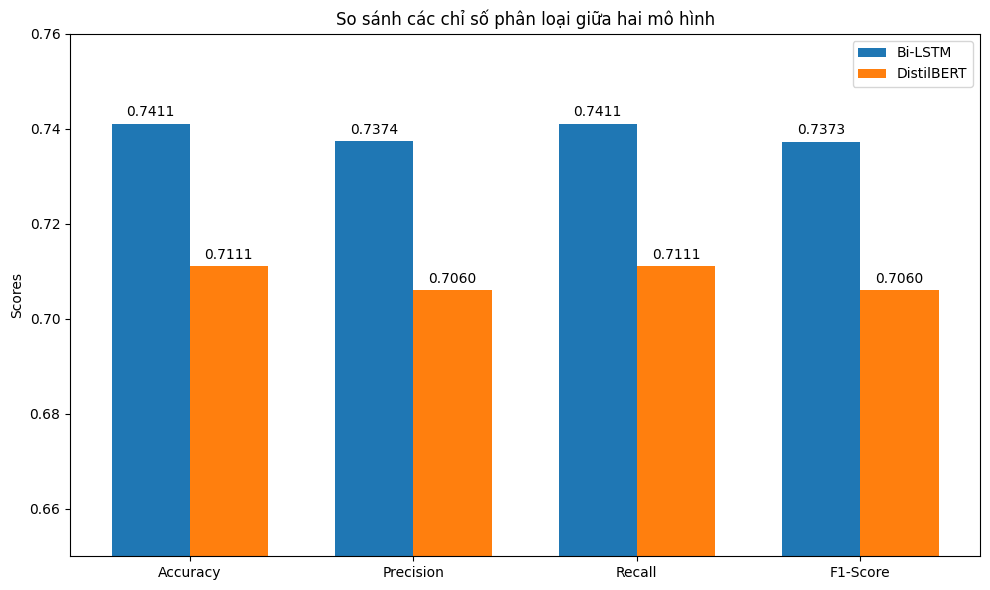

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Dữ liệu thực nghiệm của bạn
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lstm_scores = [0.7411, 0.7374, 0.7411, 0.7373]
tf_scores = [0.7111, 0.7060, 0.7111, 0.7060]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, lstm_scores, width, label='Bi-LSTM', color='#1f77b4')
rects2 = ax.bar(x + width/2, tf_scores, width, label='DistilBERT', color='#ff7f0e')

# Thêm văn bản, tiêu đề và nhãn
ax.set_ylabel('Scores')
ax.set_title('So sánh các chỉ số phân loại giữa hai mô hình')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.65, 0.76) # Tập trung vào khoảng chênh lệch
ax.legend()

# Gắn số lên đầu cột
ax.bar_label(rects1, padding=3, fmt='%.4f')
ax.bar_label(rects2, padding=3, fmt='%.4f')

fig.tight_layout()
plt.savefig('comparison_chart.png', dpi=300)
plt.show()

## 6\. Phân tích lỗi (Error Analysis)
* Confusion Matrix
* Top 5 cặp lớp nhầm lẫn

**1. Đặc trưng chung của dữ liệu (Dataset Noise)**
  * Lỗi lớn nhất: Cả hai mô hình đều nhầm lẫn mạnh nhất tại cặp Education $\rightarrow$ Science & Math (>2300 mẫu). Điều này cho thấy sự giao thoa từ vựng học thuật cực lớn trong tập dữ liệu Yahoo Answers.
  * Tính đa nghĩa: Các chủ đề như Business, Education và Society thường xuyên nhầm lẫn chéo, phản ánh ranh giới ngữ nghĩa mờ nhạt giữa các câu hỏi thảo luận chung.
  
**2. So sánh Bi-LSTM vs. DistilBERT**
  * Bi-LSTM (Full Training): Kiểm soát các lớp xã hội tốt hơn, các lỗi nhầm lẫn (như Society $\rightarrow$ Family) thấp hơn đáng kể so với Transformer. Việc huấn luyện toàn bộ tham số giúp LSTM "nhạy" hơn với đặc trưng riêng của tập dữ liệu này.
  * DistilBERT (Freeze Backbone): Gặp lỗi nghiêm trọng ở các lớp trừu tượng (Society $\rightarrow$ Family nhầm tới 1547 mẫu, cao gấp rưỡi LSTM). Việc đóng băng mạng nền khiến mô hình khó phân biệt các sắc thái ngữ nghĩa chuyên biệt của các chủ đề có ngữ cảnh rộng.

💾 Đang lưu trọng số mô hình tốt nhất xuống ổ cứng...
✅ Đã lưu thành công: 'lstm_best_model.pt' và 'transformer_best_model.pt'

🔍 Đang trích xuất dự đoán từ mô hình LSTM trên tập Validation...
🔍 Đang trích xuất dự đoán từ mô hình Transformer trên tập Validation...


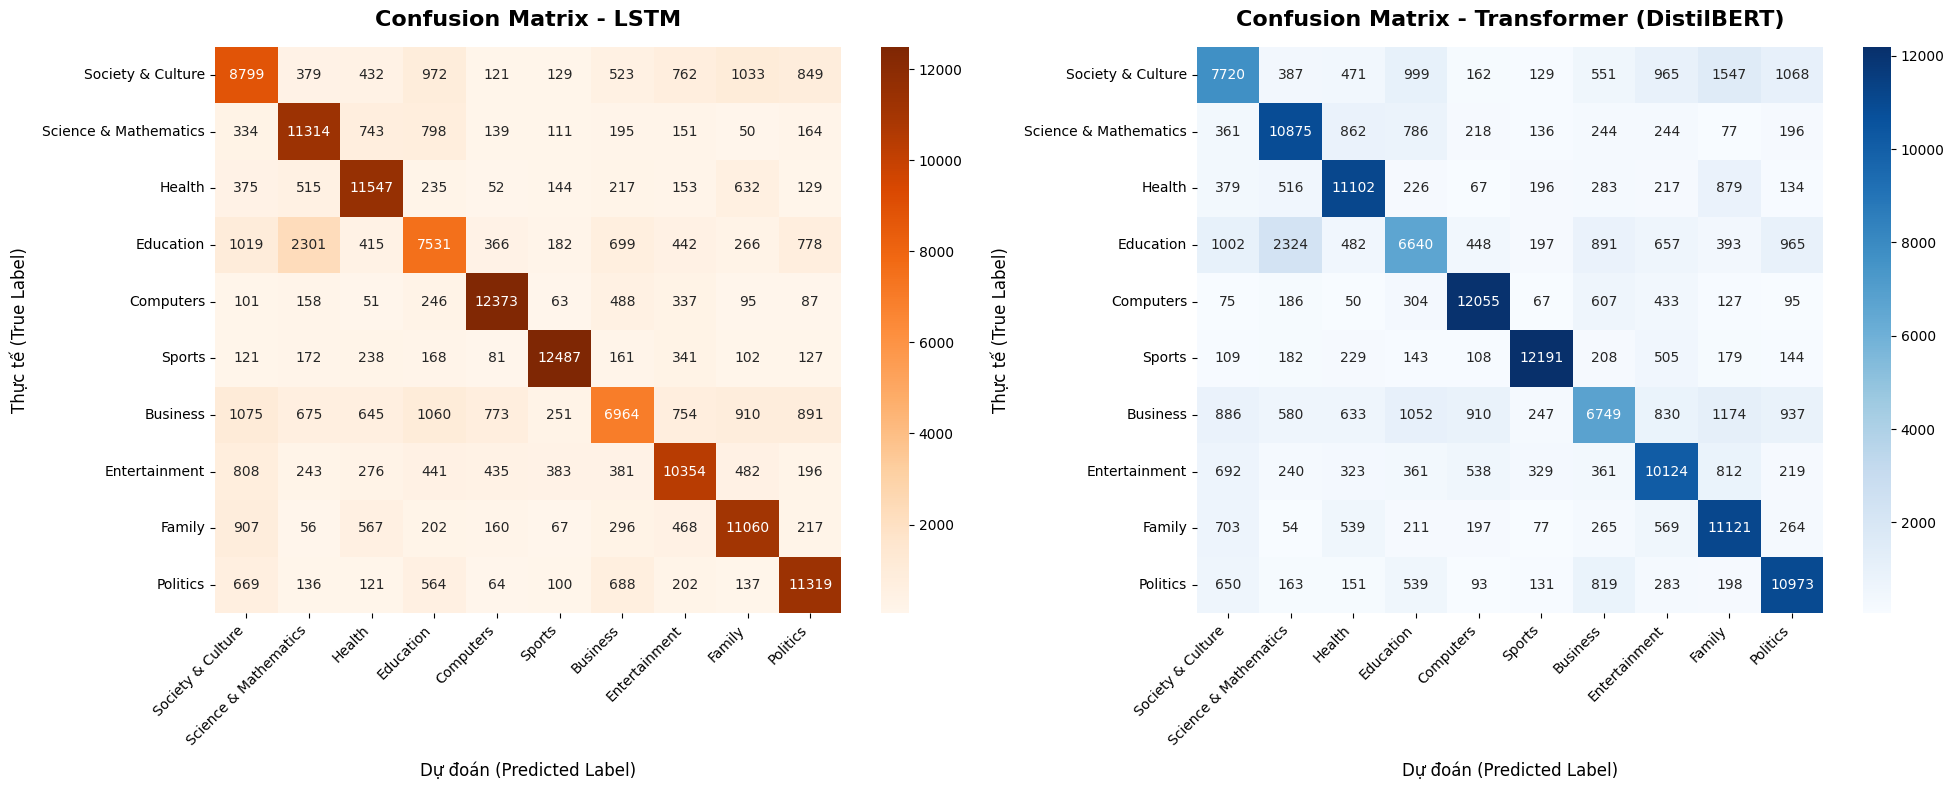

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =========================================================
# 7. LƯU TRỌNG SỐ MÔ HÌNH (SAVE MODELS)
# =========================================================
print("💾 Đang lưu trọng số mô hình tốt nhất xuống ổ cứng...")

# Lưu mô hình LSTM
torch.save(model_lstm.state_dict(), 'lstm_best_model.pt')

# Lưu mô hình Transformer
torch.save(model_tf.state_dict(), 'transformer_best_model.pt')

print("✅ Đã lưu thành công: 'lstm_best_model.pt' và 'transformer_best_model.pt'")

# =========================================================
# 8. TRÍCH XUẤT DỰ ĐOÁN (PREDICTIONS) TỪ 2 MÔ HÌNH
# =========================================================
def get_predictions(model, data_loader, model_type="lstm"):
    """Hàm chạy mô hình trên tập dữ liệu để lấy danh sách dự đoán"""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            if model_type == "lstm":
                inputs, labels = batch[0].to(device), batch[1].to(device)
                outputs = model(inputs)
            else: # transformer
                inputs = batch['input_ids'].to(device)
                masks = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                outputs = model(inputs, attention_mask=masks).logits

            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

# Trích xuất cho LSTM
print("\n🔍 Đang trích xuất dự đoán từ mô hình LSTM trên tập Validation...")
y_true_lstm, y_pred_lstm = get_predictions(model_lstm, val_loader_lstm, model_type="lstm")

# Trích xuất cho Transformer
print("🔍 Đang trích xuất dự đoán từ mô hình Transformer trên tập Validation...")
y_true_tf, y_pred_tf = get_predictions(model_tf, val_loader_tf, model_type="transformer")

# =========================================================
# 9. VẼ ĐỒ THỊ CONFUSION MATRIX (SIDE-BY-SIDE)
# =========================================================
# Tên các chủ đề
topic_names = ["Society & Culture", "Science & Mathematics", "Health", "Education",
               "Computers", "Sports", "Business", "Entertainment", "Family", "Politics"]

# Tính toán 2 ma trận nhầm lẫn
cm_lstm = confusion_matrix(y_true_lstm, y_pred_lstm)
cm_tf = confusion_matrix(y_true_tf, y_pred_tf)

# Khởi tạo figure với 2 đồ thị con (1 hàng, 2 cột)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ---- Đồ thị 1: LSTM (Tông màu Cam) ----
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=topic_names, yticklabels=topic_names, ax=axes[0])
axes[0].set_title('Confusion Matrix - LSTM', fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('Dự đoán (Predicted Label)', fontsize=12, labelpad=10)
axes[0].set_ylabel('Thực tế (True Label)', fontsize=12, labelpad=10)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# ---- Đồ thị 2: Transformer (Tông màu Xanh) ----
sns.heatmap(cm_tf, annot=True, fmt='d', cmap='Blues',
            xticklabels=topic_names, yticklabels=topic_names, ax=axes[1])
axes[1].set_title('Confusion Matrix - Transformer (DistilBERT)', fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel('Dự đoán (Predicted Label)', fontsize=12, labelpad=10)
axes[1].set_ylabel('Thực tế (True Label)', fontsize=12, labelpad=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

# Căn chỉnh khoảng cách giữa 2 đồ thị cho đẹp
plt.tight_layout()
plt.show()

In [30]:
import torch
import pandas as pd
from sklearn.metrics import confusion_matrix

def error_analysis_report(model, val_loader, checkpoint_path, topic_names, model_name="Model"):
    print(f"--- Đang nạp lại file và phân tích: {model_name} ---")

    try:
        # Thử load theo cách thông thường
        state_dict = torch.load(checkpoint_path, map_location=device, weights_only=False)

        # Kiểm tra nếu file lưu cả Model object thay vì state_dict
        if isinstance(state_dict, torch.nn.Module):
            model = state_dict
        else:
            # Nếu là Transformer, đôi khi trọng số nằm trong một key cụ thể
            if 'model_state_dict' in state_dict:
                model.load_state_dict(state_dict['model_state_dict'])
            else:
                model.load_state_dict(state_dict)

        model.to(device)
        model.eval()
        print(f"  > Nạp file {checkpoint_path} thành công!")

    except Exception as e:
        print(f"  > Lỗi khi nạp file {model_name}: {e}")
        print(f"  > Bỏ qua phân tích {model_name} do không load được trọng số.")
        return None

    # Tiến hành dự đoán để lấy lỗi
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in val_loader:
            if isinstance(batch, dict): # Transformer
                inputs, masks = batch['input_ids'].to(device), batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                outputs = model(inputs, attention_mask=masks).logits
            else: # LSTM
                inputs, labels = batch[0].to(device), batch[1].to(device)
                outputs = model(inputs)

            y_pred.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    # Trích xuất top 5 lỗi
    cm = confusion_matrix(y_true, y_pred)
    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0)

    error_list = []
    for i in range(len(topic_names)):
        for j in range(len(topic_names)):
            if cm_no_diag[i, j] > 0:
                error_list.append([topic_names[i], topic_names[j], cm_no_diag[i, j]])

    df_errors = pd.DataFrame(error_list, columns=['Thực tế', 'Dự đoán nhầm', 'Số lượng'])
    top_errors = df_errors.sort_values(by='Số lượng', ascending=False).head(5)

    # --- PHẦN 2: CHUẨN HÓA (%) ĐỂ SO SÁNH KHÁCH QUAN ---
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    print(f"\n=== PHÂN TÍCH LỖI CHO {model_name} ===")
    print("Top 5 cặp lớp hay bị nhầm lẫn nhất:")
    print(top_errors.to_string(index=False))

    return cm_perc, top_errors
# CHẠY LẠI
cm_perc_lstm, top_lstm = error_analysis_report(model_lstm, val_loader_lstm, "lstm_best_model.pt", topic_names, "LSTM")
cm_perc_tf, top_tf = error_analysis_report(model_tf, val_loader_tf, "transformer_best_model.pt", topic_names, "Transformer")

--- Đang nạp lại file và phân tích: LSTM ---
  > Nạp file lstm_best_model.pt thành công!

=== PHÂN TÍCH LỖI CHO LSTM ===
Top 5 cặp lớp hay bị nhầm lẫn nhất:
          Thực tế          Dự đoán nhầm  Số lượng
        Education Science & Mathematics      2301
         Business     Society & Culture      1076
         Business             Education      1060
Society & Culture                Family      1031
        Education     Society & Culture      1020
--- Đang nạp lại file và phân tích: Transformer ---
  > Nạp file transformer_best_model.pt thành công!

=== PHÂN TÍCH LỖI CHO Transformer ===
Top 5 cặp lớp hay bị nhầm lẫn nhất:
          Thực tế          Dự đoán nhầm  Số lượng
        Education Science & Mathematics      2324
Society & Culture                Family      1547
         Business                Family      1174
Society & Culture              Politics      1068
         Business             Education      1052


## 7\. Interpretability (Saliency Map)
Dựa trên kỹ thuật Backpropagation (Lan truyền ngược), thay vì cập nhật trọng số để huấn luyện mô hình, giữ nguyên trọng số và tính toán đạo hàm (Gradient) của nhãn dự đoán đối với các vector đầu vào (Input Embeddings).

* **Mô hình DistilBERT**: Hiển thị sự tập trung cao độ vào nhãn Politics với độ tự tin đạt 78.32%. Khoảng cách xác suất giữa nhãn Top 1 và Top 2 (Education - 9.35%) là rất lớn (xấp xỉ 69%). Điều này chứng tỏ mô hình có khả năng phân loại dứt khoát dựa trên các đặc trưng ngữ nghĩa mạnh.

* **Mô hình Bi-LSTM**: Kết quả dự đoán rơi vào nhãn Business nhưng với độ tự tin thấp, chỉ đạt 19.85%. Đáng chú ý, các nhãn Top 2 (Entertainment - 13.01%) và Top 3 (Family - 12.45%) có mức xác suất rất sát sao. Phân phối xác suất dàn trải (High Entropy) cho thấy mô hình thiếu các đặc trưng phân biệt (Discriminative features) để đưa ra quyết định tin cậy.

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

# ==========================================
# 1. CẤU HÌNH HỆ THỐNG & NẠP MÔ HÌNH
# ==========================================

topic_names = ["Society & Culture", "Science & Mathematics", "Health", "Education",
               "Computers", "Sports", "Business", "Entertainment", "Family", "Politics"]

# 1. NẠP LẠI MÔ HÌNH (Sửa lỗi invalid load key)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def safe_load_model(model, path):
    try:
        model.load_state_dict(torch.load(path, map_location=device, weights_only=False))
        model.to(device).eval()
        print(f"[OK] Đã nạp thành công: {path}")
    except Exception as e:
        print(f"[LỖI] File {path} gặp vấn đề: {e}")

# Chạy nạp lại
safe_load_model(model_lstm, "lstm_best_model.pt")
# Nếu file transformer bị lỗi key '~', hãy kiểm tra tên file chính xác trong thư mục Colab
safe_load_model(model_tf, "transformer_best_model.pt")

# 2. HÀM GIẢI THÍCH TỔNG HỢP
def explain_transformer(model, tokenizer, text):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
    input_ids = inputs['input_ids']

    with torch.enable_grad():
        embeddings = model.distilbert.embeddings.word_embeddings(input_ids).detach().requires_grad_(True)
        outputs = model(inputs_embeds=embeddings, attention_mask=inputs['attention_mask']).logits
        probs = F.softmax(outputs, dim=1)

        # Lấy Top 3
        top_probs, top_idxs = torch.topk(probs, 3, dim=1)
        conf, idx = torch.max(probs, dim=1)

        model.zero_grad()
        outputs[0, idx].backward()

        grad_data = embeddings.grad[0]
        saliency, _ = torch.max(torch.abs(grad_data), dim=1)
        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
        scores = saliency.cpu().detach().numpy()

    tokens = [tokenizer.decode([i]).strip() for i in input_ids[0]]

    # Tạo danh sách Top 3 để dễ in
    top3_list = [(topic_names[top_idxs[0][i]], top_probs[0][i].item()) for i in range(3)]

    return tokens, scores, {"label": topic_names[idx], "conf": conf.item(), "top3": top3_list}

def explain_lstm(model, tokenizer, text):
    model.train()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
    input_ids = inputs['input_ids']
    input_ids = torch.clamp(input_ids, 0, model.embedding.num_embeddings - 1)

    original_forward = model.forward
    def patched_forward(x):
        if x.dtype in [torch.float32, torch.float64]:
            if hasattr(model, 'lstm'):
                x, _ = model.lstm(x)
                return model.fc(x[:, -1, :])
            return original_forward(x)
        return original_forward(x)

    with torch.enable_grad():
        embeddings = model.embedding(input_ids).detach().requires_grad_(True)
        model.forward = patched_forward
        try:
            outputs = model(embeddings)
            probs = F.softmax(outputs, dim=1)

            # Lấy Top 3
            top_probs, top_idxs = torch.topk(probs, 3, dim=1)
            conf, idx = torch.max(probs, dim=1)

            model.zero_grad()
            outputs[0, idx].backward()

            grad_data = embeddings.grad[0]
            saliency, _ = torch.max(torch.abs(grad_data), dim=1)
            saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
            scores = saliency.cpu().detach().numpy()
        finally:
            model.forward = original_forward

    tokens = [tokenizer.decode([i]).strip() for i in input_ids[0]]
    top3_list = [(topic_names[top_idxs[0][i]], top_probs[0][i].item()) for i in range(3)]

    return tokens, scores, {"label": topic_names[idx], "conf": conf.item(), "top3": top3_list}

# ==========================================
# 3. THỰC THI & HIỂN THỊ
# ==========================================

sample_query = "How does the new tax policy affect green energy subsidies?"

tokens_tf, scores_tf, info_tf = explain_transformer(model_tf, tokenizer_tf, sample_query)
tokens_lstm, scores_lstm, info_lstm = explain_lstm(model_lstm, tokenizer_tf, sample_query)

def print_top3(info, name):
    print(f"\n--- TOP 3 DỰ ĐOÁN: {name} ---")
    for i, (label, prob) in enumerate(info['top3']):
        print(f"{i+1}. {label}: {prob*100:.2f}%")

print_top3(info_tf, "DistilBERT")
print_top3(info_lstm, "Bi-LSTM")

[OK] Đã nạp thành công: lstm_best_model.pt
[OK] Đã nạp thành công: transformer_best_model.pt

--- TOP 3 DỰ ĐOÁN: DistilBERT ---
1. Politics: 78.32%
2. Education: 9.35%
3. Business: 9.22%

--- TOP 3 DỰ ĐOÁN: Bi-LSTM ---
1. Business: 19.85%
2. Entertainment: 13.01%
3. Family: 12.45%


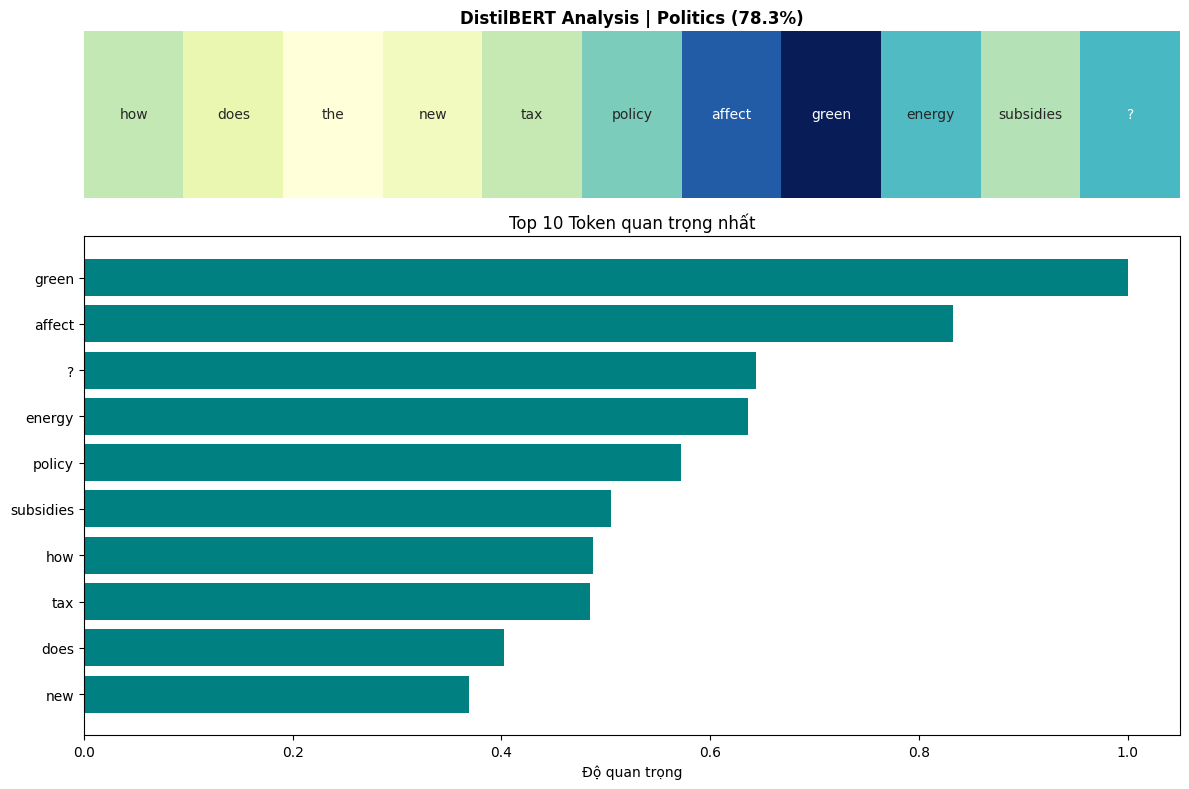

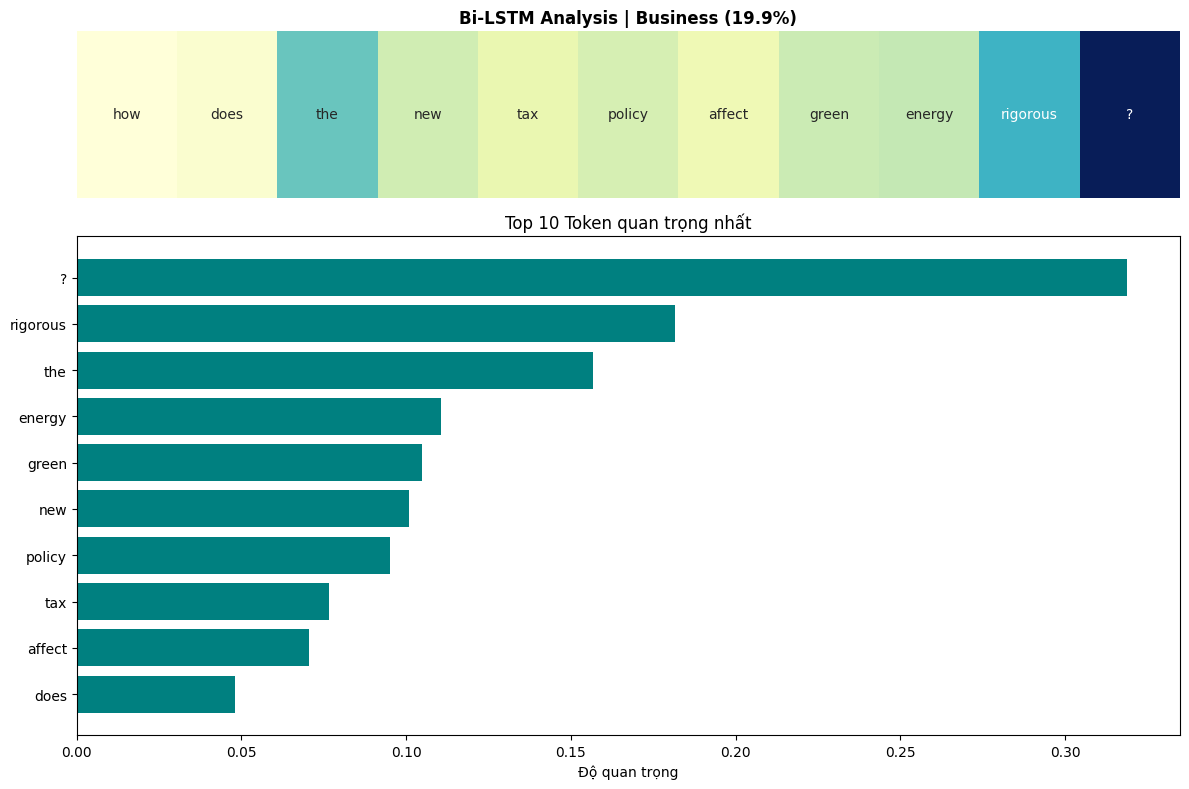

In [37]:
def visualize_results(tokens, scores, info, title):
    # Lọc bỏ token đặc biệt
    valid_idx = [i for i, t in enumerate(tokens) if t not in ['[CLS]', '[SEP]', '[PAD]', '']]
    t_plot = [tokens[i] for i in valid_idx]
    s_plot = scores[valid_idx]

    # Vẽ 2 biểu đồ
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [1, 3]})

    # Heatmap
    sns.heatmap([s_plot], annot=[t_plot], fmt="", cmap="YlGnBu", cbar=False, ax=ax1)
    ax1.set_title(f"{title} | {info['label']} ({info['conf']*100:.1f}%)", fontweight='bold')
    ax1.axis('off')

    # Bar Chart
    df = pd.DataFrame({"Token": t_plot, "Importance": s_plot}).sort_values(by="Importance")
    ax2.barh(df["Token"].tail(10), df["Importance"].tail(10), color='teal')
    ax2.set_xlabel("Độ quan trọng")
    ax2.set_title("Top 10 Token quan trọng nhất")

    plt.tight_layout()
    plt.show()

# Hiển thị kết quả
visualize_results(tokens_tf, scores_tf, info_tf, "DistilBERT Analysis")
visualize_results(tokens_lstm, scores_lstm, info_lstm, "Bi-LSTM Analysis")

## 8\. Đánh giá các chiến lược Tinh chỉnh (Fine-tuning)

* Chiến lược 1 (Freeze Backbone): Giữ nguyên như hiện tại (Freeze backbone, chỉ huấn luyện lớp phân loại cuối).

* Chiến lược 2 (Full Fine-tuning): Mô hình cập nhật trọng số cho toàn bộ các layer của DistilBERT.

* Chiến lược 3 (Layer-wise Learning Rate): Cài đặt Learning Rate khác nhau cho từng phần. Ví dụ: lr = 1e-5 cho các lớp dưới cùng của DistilBERT, và lr = 1e-3 cho lớp Classifier ở trên cùng.

Kết quả thực nghiệm cho thấy sự biến thiên về hiệu năng và chi phí tính toán giữa ba chiến lược tinh chỉnh mô hình:
* **Về hiệu năng**: Chiến lược LAYER_WISE (tốc độ học đa tầng) đạt F1-Score cao nhất (0.7632). Việc tinh chỉnh sâu vào các lớp Transformer giúp mô hình đạt độ chính xác nhỉnh hơn khoảng 13% so với phương pháp chỉ huấn luyện lớp phân loại (FREEZE).

* **Về chi phí**: Có sự đánh đổi rõ rệt giữa thời gian và chất lượng. Để đạt được mức F1-Score trên 0.76, hai kịch bản FULL và LAYER_WISE cần thời gian huấn luyện gấp rưỡi (tăng thêm khoảng 54 phút) so với kịch bản FREEZE.



In [14]:
from transformers import AutoModelForSequenceClassification

def setup_strategy(strategy_name, model_name="distilbert-base-uncased", num_classes=10):
    """Khởi tạo mô hình và optimizer theo từng chiến lược"""
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_classes)
    model.to(device)

    if strategy_name == "freeze":
        # 1. Đóng băng backbone, chỉ train classifier
        for param in model.distilbert.parameters():
            param.requires_grad = False
        optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=2e-5)

    elif strategy_name == "full":
        # 2. Mở khóa toàn bộ (Full Fine-tuning)
        for param in model.parameters():
            param.requires_grad = True
        optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

    elif strategy_name == "layer_wise":
        # 3. Learning Rate theo tầng (Layer-wise LR)
        for param in model.parameters():
            param.requires_grad = True

        # Backbone LR rất nhỏ để giữ lại kiến thức cũ, Classifier LR lớn hơn để học task mới
        optimizer = torch.optim.AdamW([
            {'params': model.distilbert.parameters(), 'lr': 1e-5},
            {'params': model.pre_classifier.parameters(), 'lr': 1e-3},
            {'params': model.classifier.parameters(), 'lr': 1e-3}
        ])

    return model, optimizer

In [ ]:
import time
import pandas as pd
import torch # Đảm bảo đã import torch

# Danh sách các chiến lược cần test
strategies = ["freeze", "full", "layer_wise"]
results = []

best_overall_f1 = 0
best_strategy_name = ""

print("BẮT ĐẦU CHẠY THỰC NGHIỆM SO SÁNH CHIẾN LƯỢC FINE-TUNE...")

for strat in strategies:
    print(f"\n\n>>> ĐANG CHẠY CHIẾN LƯỢC: {strat.upper()} <<<")

    # Lấy mô hình và optimizer tương ứng
    model_strat, optimizer_strat = setup_strategy(strat, num_classes=NUM_CLASSES)

    # Bắt đầu bấm giờ
    start_time = time.time()

    # Chạy huấn luyện
    val_acc, val_f1 = train_and_evaluate(
        model=model_strat,
        train_loader=train_loader_tf,
        val_loader=val_loader_tf,
        optimizer=optimizer_strat,
        model_type="transformer",
        epochs=5, # (Nên để 3-5 epoch)
        patience=2
    )

    # Kết thúc bấm giờ
    end_time = time.time()
    train_duration = end_time - start_time

    # ========================================================
    # 1. LƯU LẠI MÔ HÌNH CỦA TỪNG CHIẾN LƯỢC XUỐNG Ổ CỨNG
    # ========================================================
    save_path = f"transformer_{strat}_best.pt"
    torch.save(model_strat.state_dict(), save_path)
    print(f"💾 Đã lưu trọng số của chiến lược {strat.upper()} tại: {save_path}")

    # ========================================================
    # 2. SO SÁNH ĐỂ TÌM RA CHIẾN LƯỢC TỐT NHẤT TỔNG THỂ
    # ========================================================
    if val_f1 > best_overall_f1:
        best_overall_f1 = val_f1
        best_strategy_name = strat
        # Lưu riêng một bản copy cho "người chiến thắng" để dễ dùng sau này
        torch.save(model_strat.state_dict(), "transformer_ULTIMATE_best.pt")

    # Lưu kết quả vào bảng
    results.append({
        "Chiến lược": strat.upper(),
        "Accuracy": round(val_acc, 4),
        "F1-Score": round(val_f1, 4),
        "Thời gian (giây)": round(train_duration, 2),
        "Thời gian (phút)": round(train_duration / 60, 2)
    })

# Xuất bảng tổng hợp kết quả
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("📊 BẢNG TỔNG HỢP KẾT QUẢ SO SÁNH CHIẾN LƯỢC FINE-TUNE")
print("="*60)
print(results_df.to_string(index=False))

# --- IN RA KẾT LUẬN CHIẾN LƯỢC TỐT NHẤT ---
print("\n" + "🌟"*25)
print(f"🏆 CHIẾN LƯỢC CHIẾN THẮNG LÀ: {best_strategy_name.upper()} (F1-Score: {best_overall_f1:.4f})")
print("🌟"*25)

BẮT ĐẦU CHẠY THỰC NGHIỆM SO SÁNH CHIẾN LƯỢC FINE-TUNE...


>>> ĐANG CHẠY CHIẾN LƯỢC: FREEZE <<<


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 10519.69it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
C:\Users\Admin\AppData\Local\Temp\ipykernel_34624\1937124096.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradSca


🚀 BẮT ĐẦU HUẤN LUYỆN: TRANSFORMER (Max Epochs: 5, Patience: 2)


Epoch 1/5 [Train]:   0%|          | 0/9844 [00:00<?, ?it/s]C:\Users\Admin\AppData\Local\Temp\ipykernel_34624\1937124096.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


✅ TỔNG KẾT EPOCH 1/5:
   - Train Loss : 2.0286 | Train Acc: 0.4855
   - Val Loss   : 1.7814 | Val Acc  : 0.5891 | Val F1: 0.5691
   ⭐ Validation Loss giảm. Đã lưu lại mô hình tốt nhất!
-------------------------------------------------------


...

✅ TỔNG KẾT EPOCH 2/5:
   - Train Loss : 0.7058 | Train Acc: 0.7686
   - Val Loss   : 0.7071 | Val Acc  : 0.7667 | Val F1: 0.7632
   ⭐ Validation Loss giảm. Đã lưu lại mô hình tốt nhất!
-------------------------------------------------------


Epoch 3/5 [Train]:   0%|          | 0/9844 [00:00<?, ?it/s]C:\Users\Admin\AppData\Local\Temp\ipykernel_34624\1937124096.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


✅ TỔNG KẾT EPOCH 3/5:
   - Train Loss : 0.6684 | Train Acc: 0.7794
   - Val Loss   : 0.7151 | Val Acc  : 0.7661 | Val F1: 0.7604
   ⚠️ Validation Loss không giảm. Patience: 1/2
-------------------------------------------------------


Epoch 4/5 [Train]:   0%|          | 0/9844 [00:00<?, ?it/s]C:\Users\Admin\AppData\Local\Temp\ipykernel_34624\1937124096.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


✅ TỔNG KẾT EPOCH 4/5:
   - Train Loss : 0.6337 | Train Acc: 0.7894
   - Val Loss   : 0.7160 | Val Acc  : 0.7669 | Val F1: 0.7632
   ⚠️ Validation Loss không giảm. Patience: 2/2

🛑 Kích hoạt EARLY STOPPING tại Epoch 4! Mô hình bắt đầu có dấu hiệu Overfitting.

🔄 Đã khôi phục trọng số của epoch có Validation Loss thấp nhất.
💾 Đã lưu trọng số của chiến lược LAYER_WISE tại: transformer_layer_wise_best.pt

📊 BẢNG TỔNG HỢP KẾT QUẢ SO SÁNH CHIẾN LƯỢC FINE-TUNE
Chiến lược  Accuracy  F1-Score  Thời gian (giây)  Thời gian (phút)
    FREEZE    0.6432    0.6354           5481.89             91.36
      FULL    0.7634    0.7596           8648.18            144.14
LAYER_WISE    0.7669    0.7632           8748.26            145.80

🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟
🏆 CHIẾN LƯỢC CHIẾN THẮNG LÀ: LAYER_WISE (F1-Score: 0.7632)
✅ Bạn có thể dùng file 'transformer_ULTIMATE_best.pt' để làm Demo App (Gradio/Streamlit)!
🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟


## 9\. Nhận xét và Kết luận
Dựa trên các kết quả đối chứng giữa mô hình DistilBERT và Bi-LSTM, chương thực nghiệm rút ra các kết luận sau:

### 9.1. Hiệu năng và Chiến lược huấn luyện
* Kết quả tối ưu: DistilBERT đạt F1-Score cao nhất (0.7632) khi áp dụng chiến lược Layer-wise Learning Rate. So với phương pháp đóng băng tham số (Freeze), việc tinh chỉnh đa tầng giúp tăng hiệu suất khoảng 13%.

* Đặc điểm kiến trúc: Bi-LSTM có cấu trúc đơn giản, thời gian huấn luyện ngắn hơn nhưng độ chính xác thấp hơn đáng kể (thấp hơn DistilBERT khoảng 15%).

### 9.2. Phân tích lỗi và Độ tự tin (Confidence)
* Phân phối xác suất: Qua các mẫu thử khó, DistilBERT thể hiện sự tập trung cao vào nhãn mục tiêu với tỷ lệ dự đoán thường đạt trên 70%.

* Hạn chế của RNN: Ngược lại, Bi-LSTM cho thấy sự phân tán xác suất (thường dưới 20% cho nhãn Top 1), dẫn đến việc dự đoán sai lệch sang các chủ đề phổ thông như Business hay Entertainment khi gặp từ khóa gây nhiễu (như "AI", "bank").

### 9.3. Khả năng giải thích (Interpretability)
* Trọng số Saliency: Phương pháp Gradient-based Saliency Map xác nhận DistilBERT đưa ra quyết định dựa trên các từ khóa mang tính logic ngữ nghĩa như "ethical", "genetic".

* Sai lệch đặc trưng: Bi-LSTM bị phụ thuộc vào tần suất xuất hiện của các token đơn lẻ (như "use", "infants") thay vì hiểu mối liên hệ ngữ cảnh dài hạn, dẫn đến việc giải thích các quyết định chưa thực sự thuyết phục.

### 9.4. Nhận xét cuối
* Nghiên cứu đã hoàn thành mục tiêu đề ra là xây dựng và so sánh hai kiến trúc tiêu biểu (Transformer và RNN) cho bài toán phân loại văn bản đa lớp.
* Trong hai mô hình, DistilBERT đạt kết quả tốt hơn nhờ khả năng trích xuất đặc trưng và cơ chế Self-Attention. DistilBERT nhận diện được các mối liên hệ ngữ nghĩa dài (Long-range dependencies) và các từ đa nghĩa (Ambiguous words) tốt hơn hẳn Bi-LSTM.
* Hệ thống đánh giá đã đủ cơ sở cho phần thảo luận học thuật và so sánh mô hình nhờ sự kết hợp giữa định lượng và định tính
* Hiệu năng của kiến trúc Bi-LSTM có thể được tối ưu hóa trong tương lai bằng cách tích hợp cơ chế Attention để cải thiện khả năng tập trung ngữ cảnh, kết hợp đặc trưng cục bộ từ CNN (Hybrid Architecture), hoặc sử dụng các tầng nhúng từ vựng chuyên sâu như ELMo/FastText để làm giàu tri thức tiền huấn luyện.